In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/val/orange/251acea001.jpg
/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/val/orange/4eff9ff2ad.jpg
/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/val/orange/b790d568bc.jpg
/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/val/orange/386e3b929b.jpg
/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/val/orange/e3288abf91.jpg
/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/val/orange/f3a0ddc562.jpg
/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/val/orange/8d8cc4e998.jpg
/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/val/orange/5ce6ea8649.jpg
/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/val/orange/f1c3dbe9db.jpg
/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/val/or

In [2]:
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-06-12 19:38:20.979616: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781293101.174034      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781293101.227920      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781293101.661922      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781293101.661993      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781293101.661996      23 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
BASE_DIR = "/kaggle/input"
for root, dirs, files in os.walk(BASE_DIR):
    depth = root[len(BASE_DIR):].count(os.sep)
    indent = "  " * depth
    print(f"{indent}{root}  ->  dirs: {dirs[:10]}  files: {len(files)}")
    if depth >= 4:
        dirs[:] = []  # stop going deeper than this

/kaggle/input  ->  dirs: ['datasets']  files: 0
  /kaggle/input/datasets  ->  dirs: ['landrykezebou']  files: 0
    /kaggle/input/datasets/landrykezebou  ->  dirs: ['vcor-vehicle-color-recognition-dataset']  files: 0
      /kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset  ->  dirs: ['val', 'test', 'train']  files: 0
        /kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/val  ->  dirs: ['orange', 'tan', 'yellow', 'purple', 'silver', 'grey', 'pink', 'black', 'gold', 'blue']  files: 0
        /kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/test  ->  dirs: ['orange', 'tan', 'yellow', 'purple', 'silver', 'grey', 'pink', 'black', 'gold', 'blue']  files: 0
        /kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/train  ->  dirs: ['orange', 'tan', 'yellow', 'purple', 'silver', 'grey', 'pink', 'black', 'gold', 'blue']  files: 0


In [4]:
DATASET_DIR = "/kaggle/input/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR = os.path.join(DATASET_DIR, "test")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

Images per class (train):
  beige       : 421
  black       : 406
  blue        : 742
  brown       : 565
  gold        : 210
  green       : 563
  grey        : 428
  orange      : 534
  pink        : 483
  purple      : 536
  red         : 637
  silver      : 362
  tan         : 400
  white       : 403
  yellow      : 577


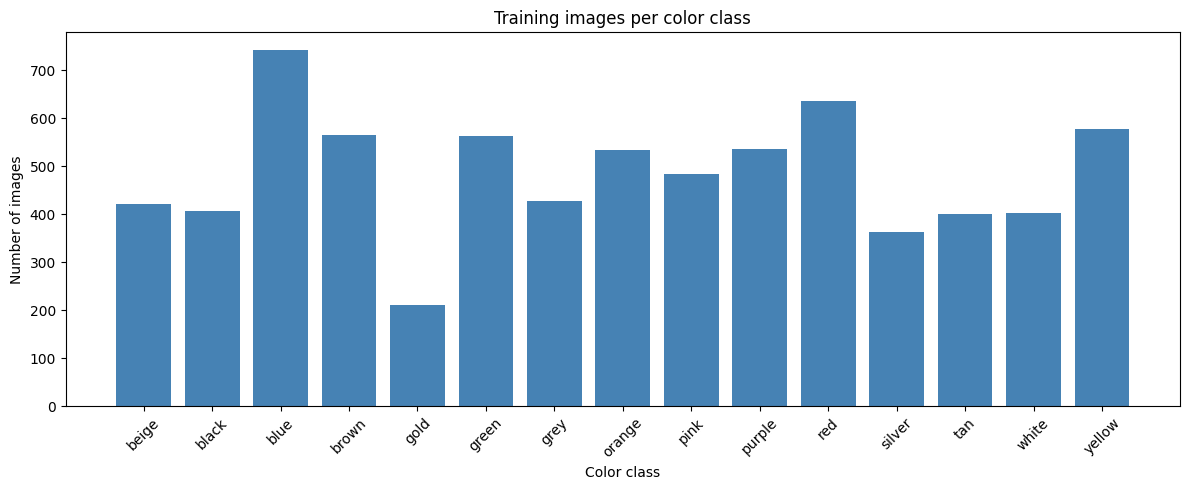

In [5]:
class_counts = {}
for class_name in sorted(os.listdir(TRAIN_DIR)):
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print("Images per class (train):")
for k, v in class_counts.items():
    print(f"  {k:12s}: {v}")

plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values(), color="steelblue")
plt.title("Training images per color class")
plt.xlabel("Color class")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

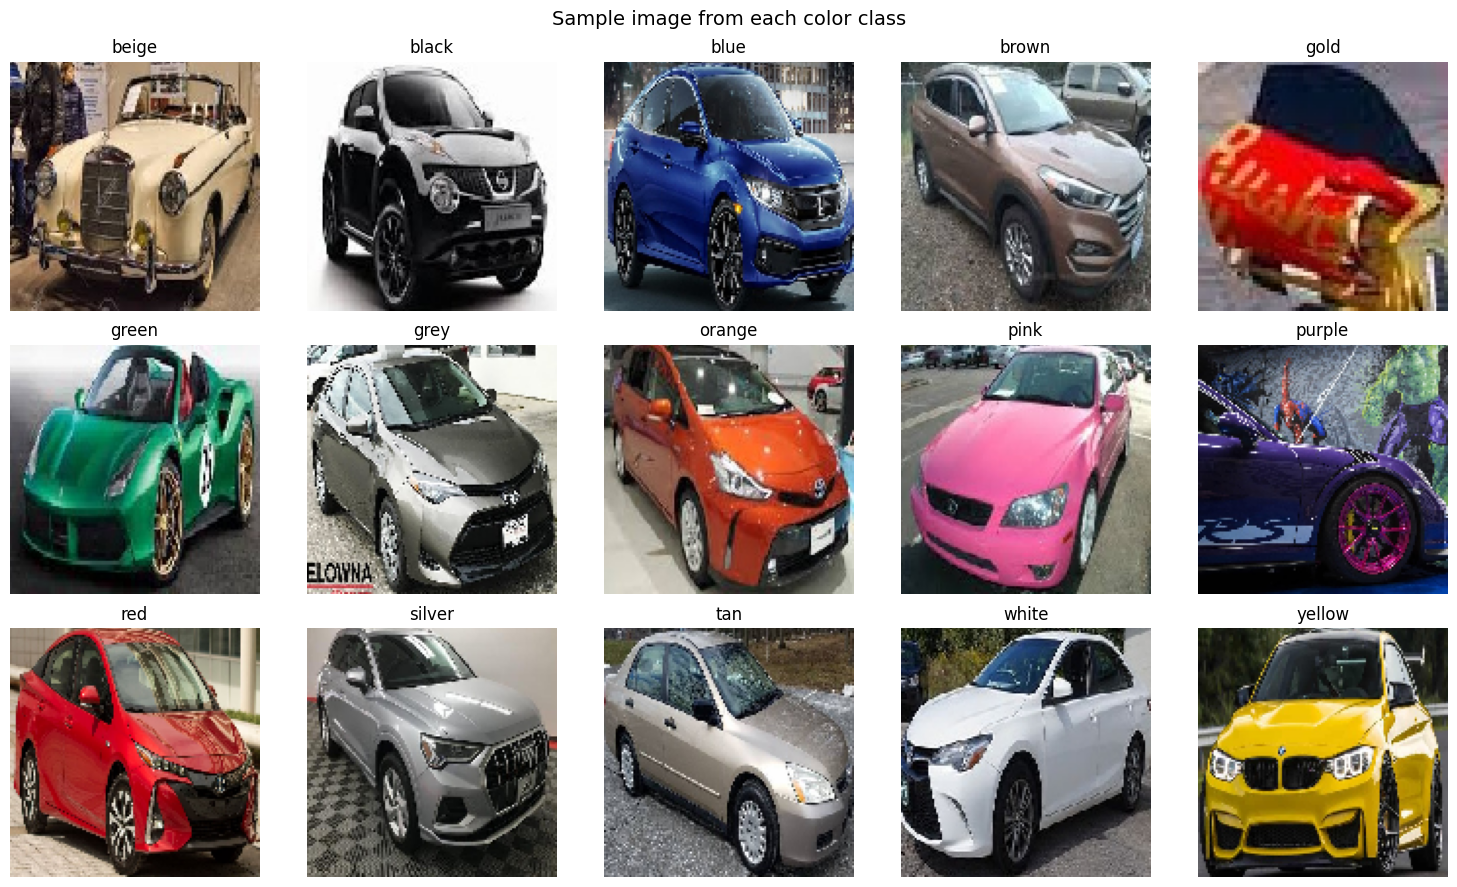

In [6]:
class_names_sorted = sorted(class_counts.keys())
n_classes = len(class_names_sorted)
n_cols = 5
n_rows = int(np.ceil(n_classes / n_cols))

plt.figure(figsize=(15, 3 * n_rows))
for i, class_name in enumerate(class_names_sorted):
    class_path = os.path.join(TRAIN_DIR, class_name)
    sample_file = os.listdir(class_path)[0]
    img = tf.keras.utils.load_img(os.path.join(class_path, sample_file), target_size=IMG_SIZE)
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")
plt.suptitle("Sample image from each color class", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    seed=SEED,
    shuffle=False,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

AUTOTUNE = tf.data.AUTOTUNE
train_ds_p = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds_p = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 7267 files belonging to 15 classes.


I0000 00:00:1781293121.015731      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781293121.021871      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1556 files belonging to 15 classes.
Classes: ['beige', 'black', 'blue', 'brown', 'gold', 'green', 'grey', 'orange', 'pink', 'purple', 'red', 'silver', 'tan', 'white', 'yellow']
Number of classes: 15


In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = layers.Rescaling(1.0 / 127.5, offset=-1)(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
EPOCHS_PHASE1 = 10

history1 = model.fit(
    train_ds_p,
    validation_data=val_ds_p,
    epochs=EPOCHS_PHASE1,
)

Epoch 1/10


I0000 00:00:1781293133.998005      77 cuda_dnn.cc:529] Loaded cuDNN version 91002


228/228 ━━━━━━━━━━━━━━━━━━━━ 31s 92ms/step - accuracy: 0.4416 - loss: 1.7630 - val_accuracy: 0.5758 - val_loss: 1.2966
Epoch 2/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.6313 - loss: 1.1064 - val_accuracy: 0.6446 - val_loss: 1.0983
Epoch 3/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.6669 - loss: 0.9735 - val_accuracy: 0.6555 - val_loss: 1.0321
Epoch 4/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.6860 - loss: 0.9109 - val_accuracy: 0.6613 - val_loss: 1.0204
Epoch 5/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.7043 - loss: 0.8612 - val_accuracy: 0.6729 - val_loss: 0.9816
Epoch 6/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.7146 - loss: 0.8313 - val_accuracy: 0.6844 - val_loss: 0.9777
Epoch 7/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.7205 - loss: 0.8154 - val_accuracy: 0.6928 - val_loss: 0.9474
Epoch 8/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.7235 - loss: 0.7938 - val_accuracy: 0.69

In [10]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

EPOCHS_PHASE2 = 5

history2 = model.fit(
    train_ds_p,
    validation_data=val_ds_p,
    epochs=EPOCHS_PHASE2,
)

Epoch 1/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.6340 - loss: 1.2113 - val_accuracy: 0.6780 - val_loss: 0.9581
Epoch 2/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.6787 - loss: 1.0029 - val_accuracy: 0.6799 - val_loss: 0.9448
Epoch 3/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.6997 - loss: 0.9106 - val_accuracy: 0.6928 - val_loss: 0.9022
Epoch 4/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.7204 - loss: 0.8568 - val_accuracy: 0.7044 - val_loss: 0.8745
Epoch 5/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.7226 - loss: 0.8292 - val_accuracy: 0.7082 - val_loss: 0.8413


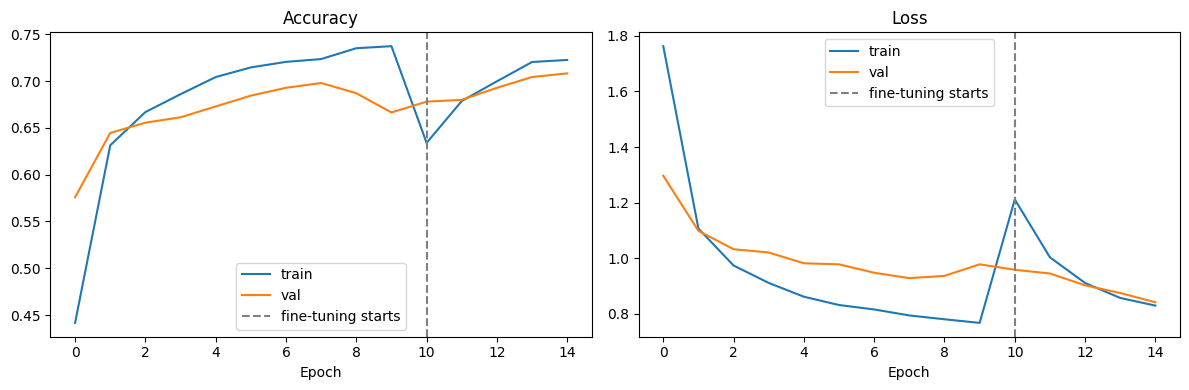

In [11]:
acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]
loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]
switch_epoch = len(history1.history["accuracy"])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label="train")
plt.plot(val_acc, label="val")
plt.axvline(switch_epoch, color="gray", linestyle="--", label="fine-tuning starts")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label="train")
plt.plot(val_loss, label="val")
plt.axvline(switch_epoch, color="gray", linestyle="--", label="fine-tuning starts")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
val_loss_final, val_acc_final = model.evaluate(val_ds_p)
print(f"Final validation accuracy: {val_acc_final:.3f}")
print(f"Final validation loss: {val_loss_final:.3f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7082 - loss: 0.8413
Final validation accuracy: 0.708
Final validation loss: 0.841


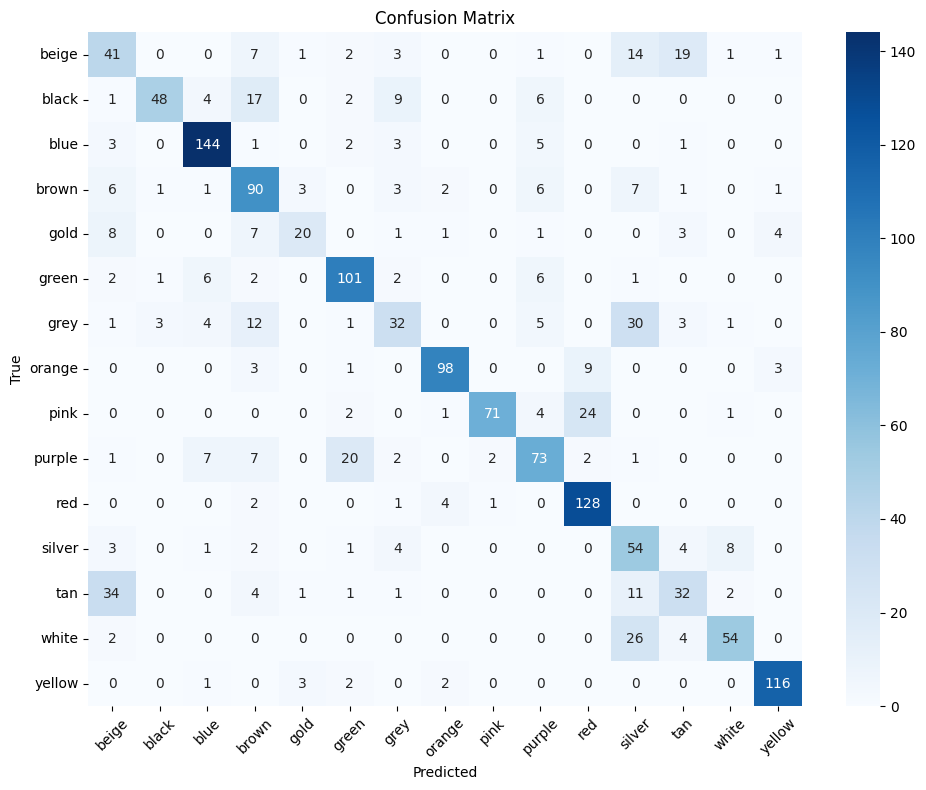


Classification Report:
              precision    recall  f1-score   support

       beige       0.40      0.46      0.43        90
       black       0.91      0.55      0.69        87
        blue       0.86      0.91      0.88       159
       brown       0.58      0.74      0.65       121
        gold       0.71      0.44      0.55        45
       green       0.75      0.83      0.79       121
        grey       0.52      0.35      0.42        92
      orange       0.91      0.86      0.88       114
        pink       0.96      0.69      0.80       103
      purple       0.68      0.63      0.66       115
         red       0.79      0.94      0.86       136
      silver       0.38      0.70      0.49        77
         tan       0.48      0.37      0.42        86
       white       0.81      0.63      0.71        86
      yellow       0.93      0.94      0.93       124

    accuracy                           0.71      1556
   macro avg       0.71      0.67      0.68      1556
we

In [13]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [14]:
model.save("/kaggle/working/car_color_model.keras")

with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Saved model and class_names.json to /kaggle/working/")

Saved model and class_names.json to /kaggle/working/


In [15]:
import os
print(os.listdir("/kaggle/working"))

['class_names.json', '__notebook__.ipynb', 'car_color_model.keras']


In [16]:
from IPython.display import FileLink
display(FileLink("car_color_model.keras"))
display(FileLink("class_names.json"))

/kaggle/working/car_color_model.keras

/kaggle/working/class_names.json